In [ ]:
import sys
import os

sys.path.append(os.path.abspath(os.path.join('..')))

In [8]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from neural_nets.models import FlowMapNetwork
from sklearn.datasets import make_moons


In [18]:

def generate_animation(model_path, save_path="flow_animation.gif", interpolant='linear',n_points=500, n_frames=100):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"🎥 Génération de l'animation sur {device}...")

    # 1. Charger le Modèle Student
    model = FlowMapNetwork(data_dim=2, hidden_dim=128, time_dim=64).to(device)
    model.load_state_dict(torch.load(model_path, map_location=device))
    model.eval()

    x0 = torch.randn(n_points, 2).to(device)
    
    x_target, _ = make_moons(n_samples=n_points, noise=0.05)
    x_target = (x_target - 0.5) / 0.6
    
    print("⚡ Pré-calcul des trajectoires...")
    trajectories = []
    
    times = torch.linspace(0, 1, n_frames).to(device)
    s = torch.zeros(n_points, 1).to(device)
    
    with torch.no_grad():
        for t_val in times:
            t_vec = torch.ones(n_points, 1).to(device) * t_val
            
            xt = model(x0, s, t_vec)
            trajectories.append(xt.cpu().numpy())
            
    trajectories = np.array(trajectories) 

    print("Création de la vidéo...")
    fig, ax = plt.subplots(figsize=(8, 8))
    ax.set_xlim(-3, 3)
    ax.set_ylim(-3, 3)
    ax.set_title(f"Flow Map Matching: Transport (t=0.00) | {interpolant}")
    
    ax.scatter(x_target[:, 0], x_target[:, 1], c='red', alpha=0.1, label='Target (Data)')
    
    scat = ax.scatter(trajectories[0, :, 0], trajectories[0, :, 1], c='blue', alpha=0.6, s=10, label='Flow (Generated)')
    ax.legend(loc='upper right')

    def update(frame):
        current_pos = trajectories[frame]
        scat.set_offsets(current_pos)
        
        t_current = frame / (n_frames - 1)
        ax.set_title(f"Flow Map Matching: Transport (t={t_current:.2f})")
        return scat,

    ani = animation.FuncAnimation(fig, update, frames=n_frames, interval=50, blit=True)

    print(f"💾 Sauvegarde dans {save_path}...")
    try:
        ani.save(save_path, writer='pillow', fps=20)
        print("✅ Animation terminée !")
    except Exception as e:
        print(f"❌ Erreur lors de la sauvegarde : {e}")
        print("Essayez d'installer ffmpeg ou utilisez l'extension .mp4")


🎥 Génération de l'animation sur cpu...
⚡ Pré-calcul des trajectoires...
🎨 Création de la vidéo...
💾 Sauvegarde dans flow_animation.gif...
✅ Animation terminée !


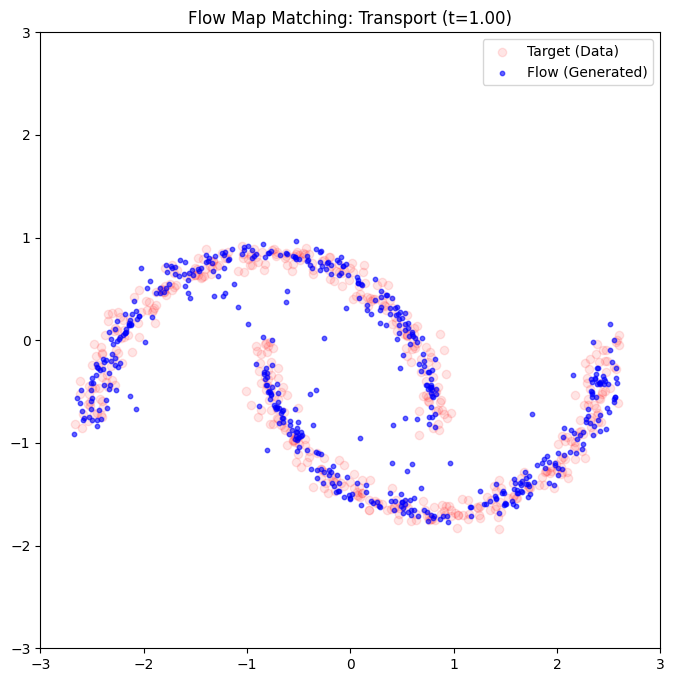

In [17]:
STUDENT_PATH_linear = "../../checkpoints/flow_map_student.pth" 
generate_animation(STUDENT_PATH_linear, interpolant='linear')

🎥 Génération de l'animation sur cpu...
⚡ Pré-calcul des trajectoires...
Création de la vidéo...
💾 Sauvegarde dans flow_animation_stochastic.gif...
✅ Animation terminée !


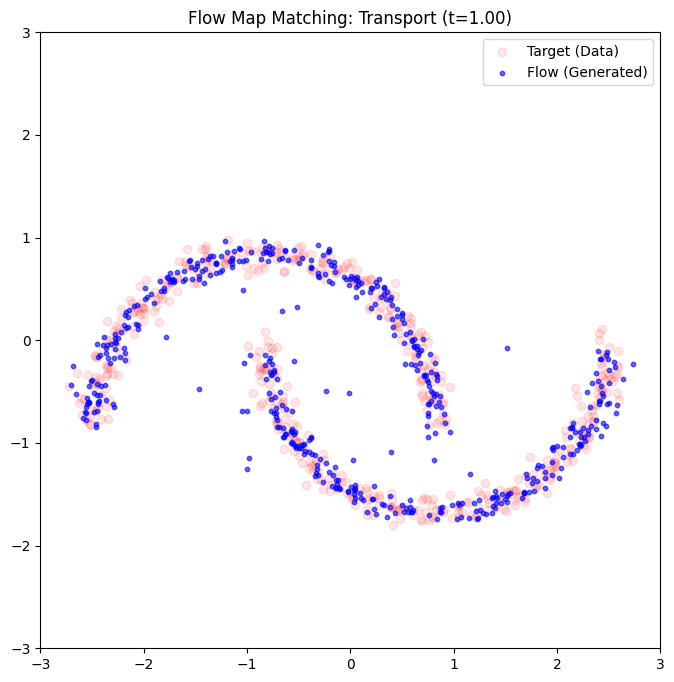

In [20]:
STUDENT_PATH_linear = "../../checkpoints/flow_map_student_stochastic_teacher.pth" 
generate_animation(STUDENT_PATH_linear, save_path='flow_animation_stochastic.gif',interpolant='stochastic')